##Artifical Neural Network

#Part 1 : Data preprocessing

##Knowing the hyperparameter optimizers


In [1]:
#Importing the Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#Importing the dataset
dataset = pd.read_csv('Churn_Modelling.csv')

In [3]:
X= dataset.iloc[:,3:13]
y= dataset.iloc[:,13]

In [4]:
#Creating dummy variables
geography= pd.get_dummies(X["Geography"],drop_first = True)
gender= pd.get_dummies(X["Gender"],drop_first = True)

In [5]:
#Concatenate the Data Frames
X= pd.concat([X,geography,gender],axis=1)

In [6]:
#Drop Unnecessary Columns
X= X.drop(['Geography','Gender'],axis=1)

In [7]:
#Splitting the dataset into the Training set and the Test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [8]:
#Feature  Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [9]:
# ##Perform HyperParameter Optimization
# You need to install scikeras to use KerasClassifier with sklearn
!pip install scikeras[tensorflow]
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

In [10]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Embedding, Flatten, LeakyReLU, BatchNormalization, Dropout
from keras.activations import relu,sigmoid

In [11]:
def create_model(layers,activation):
  model=Sequential()
  for i,nodes in enumerate(layers):
    if i==0:
      model.add(Dense(nodes,input_dim=X_train.shape[1]))
      model.add(Activation(activation))
      model.add(Dropout(0.3))
    else:
      model.add(Dense(nodes))
      model.add(Activation(activation))
      model.add(Dropout(0.3))
  model.add(Dense(units=1,kernel_initializer='glorot_uniform',activation='sigmoid'))
  model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
  return model


In [12]:
model=KerasClassifier(build_fn=create_model,verbose=0)

In [13]:
layers=[[20],[40,20],[45,30,15]]
activations=['sigmoid','relu']
param_grid=dict(model__layers=layers,model__activation=activations,batch_size=[128,256],epochs=[30])
grid=GridSearchCV(estimator=model,param_grid=param_grid,cv=5)

In [14]:
grid_result=grid.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer usin

In [18]:
# Uninstall the current scikit-learn version
!pip uninstall scikit-learn -y

# Install scikit-learn version 1.4.2
!pip install scikit-learn==1.4.2

# After running this cell, please restart your Colab runtime (Runtime -> Restart runtime)
# and then re-run the cells from 'oevg_xHdtQEr' onwards.

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [16]:
###MOdel best results
print(f"Best Score: {grid_result.best_score_}")
print(f"Best Parameters: {grid_result.best_params_}")

Best Score: 0.8561249999999999
Best Parameters: {'batch_size': 128, 'epochs': 30, 'model__activation': 'relu', 'model__layers': [45, 30, 15]}


In [17]:
pred_y=grid.predict(X_test)
y_pred=(pred_y>0.5)

In [18]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
score=accuracy_score(y_pred,y_test)

............................................................................................................

#Part -2 : Now lets make the ANN

In [ ]:
#Importing the keras Libraries and packages
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU ,PReLU,ELU
from keras.layers import Dropout

In [ ]:
#Initialising the ANN
classifier = Sequential()

In [ ]:
#Adding the input layer and the first hidden layer
classifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu', input_dim=11))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Adding the second hidden layer
classifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu'))

In [ ]:
#Adding the output layer
classifier.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))

In [ ]:
#Compling the ANN
classifier.compile(optimizer='Adamax',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
#Fitting the ANN to the Training set
model_history = classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6216 - loss: 0.7500 - val_accuracy: 0.7054 - val_loss: 0.6246
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7455 - loss: 0.5632 - val_accuracy: 0.7668 - val_loss: 0.5501
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7828 - loss: 0.5169 - val_accuracy: 0.7834 - val_loss: 0.5193
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7916 - loss: 0.4935 - val_accuracy: 0.7895 - val_loss: 0.5003
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7960 - loss: 0.4780 - val_accuracy: 0.7940 - val_loss: 0.4880
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7994 - loss: 0.4670 - val_accuracy: 0.7940 - val_loss: 0.4788
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8018 - loss: 0.4588 - val_accuracy: 0.7986 - val_loss: 0.4717
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8039 - loss: 0.4517 - val_accu

In [ ]:
#List all the data in history
print(model_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


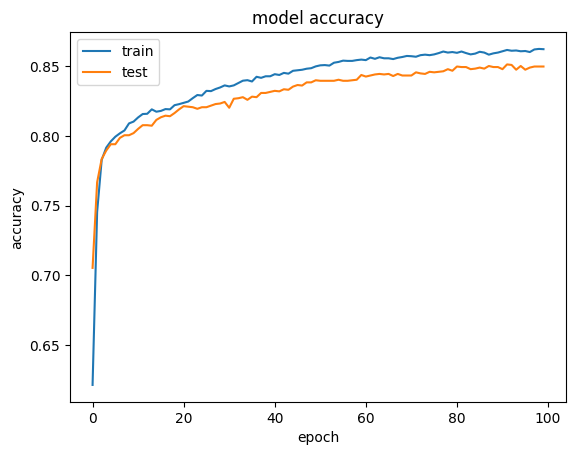

In [ ]:
#summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

#Part-3: Making the predictions and evaluating the model

In [ ]:
#Predicting the Test set results
y_pred=classifier.predict(X_test)
y_pred=(y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
#Making the Confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)

In [ ]:
cm

array([[1526,   69],
       [ 203,  202]])

In [ ]:
#Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [ ]:
score

0.864